In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('Care_Transition_Pipeline_Analysis.csv')


## Convert required columns to numeric

In [17]:
cols = [
    "CBP_Custody",
    "Transferred_to_HHS",
    "HHS_Care",
    "Discharged",
    "CBP_Intake"
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Avoid division by zero
df.replace(0, np.nan, inplace=True)

,Date,CBP_Intake,CBP_Custody,Transferred_to_HHS,HHS_Care,Discharged,Stage_1_CBP,Stage_2_HHS,Stage_3_Sponsor,Movement_CBP_to_HHS,...,Discharge_Efficiency_%,Pipeline_Throughput_%,CBP_Backlog_Change,HHS_Backlog_Change,Pipeline_Pressure,Placement_Ratio_%,Intake_7Day_Avg,Transfer_7Day_Avg,Discharge_7Day_Avg,Month
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,53.0,"6,566",436.0,34.0,...,6.640268,1321.212121,-1.0,-402.0,6619.0,1282.352941,33.000000,34.000000,436.000000,2023-01
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,49.0,"7,122",227.0,39.0,...,3.187307,709.375000,-7.0,-188.0,7171.0,582.051282,32.500000,36.500000,331.500000,2023-01
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,50.0,"7,280",181.0,39.0,...,2.486264,565.625000,-7.0,-142.0,7330.0,464.102564,32.333333,37.333333,281.333333,2023-01
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,42.0,"7,433",175.0,47.0,...,2.354366,372.340426,NaN,-128.0,7475.0,372.340426,36.000000,39.750000,254.750000,2023-01
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,22.0,"7,538",180.0,41.0,...,2.387901,900.000000,-21.0,-139.0,7560.0,439.024390,32.800000,40.000000,239.800000,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:

df["Transfer_Efficiency_Ratio"] = (
    df["Transferred_to_HHS"] /
    df["CBP_Custody"]
)

df["Transfer_Efficiency_%"] = (
    df["Transfer_Efficiency_Ratio"] * 100
).round(2)

## 2. Discharge Effectiveness
 Discharges ÷ HHS Care

In [19]:
df["Discharge_Effectiveness"] = (
    df["Discharged"] /
    df["HHS_Care"]
)

df["Discharge_Effectiveness_%"] = (
    df["Discharge_Effectiveness"] * 100
).round(2)


## 3. Pipeline Throughput Rate
 Total exits ÷ Total entries

In [20]:

total_entries = df["CBP_Intake"].sum()
total_exits = df["Discharged"].sum()

pipeline_throughput_rate = (
    total_exits / total_entries
) * 100

print(f"Pipeline Throughput Rate: {pipeline_throughput_rate:.2f}%")

Pipeline Throughput Rate: 185.42%


# ===================================================================================================================================

## 1. Compare Inflow vs Successful Exits

In [21]:

df["Daily_Backlog_Change"] = (
    df["CBP_Intake"] - df["Discharged"]
)

print(df[["Date", "CBP_Intake", "Discharged", "Daily_Backlog_Change"]].head())

         Date  CBP_Intake  Discharged  Daily_Backlog_Change
0  2023-01-12        33.0       436.0                -403.0
1  2023-01-22        32.0       227.0                -195.0
2  2023-01-23        32.0       181.0                -149.0
3  2023-01-24        47.0       175.0                -128.0
4  2023-01-25        20.0       180.0                -160.0


## 2. Cumulative Backlog

In [22]:
df["Cumulative_Backlog"] = df["Daily_Backlog_Change"].cumsum()

print(df[["Date", "Cumulative_Backlog"]].tail())

     Date  Cumulative_Backlog
1165  NaN                 NaN
1166  NaN                 NaN
1167  NaN                 NaN
1168  NaN                 NaN
1169  NaN                 NaN


## 3. Identify Sustained Imbalance Periods

In [23]:
df["Backlog_Increasing"] = df["Daily_Backlog_Change"] > 0

# Count consecutive increasing days
groups = (df["Backlog_Increasing"] != df["Backlog_Increasing"].shift()).cumsum()

df["Consecutive_Increase_Days"] = (
    df.groupby(groups)["Backlog_Increasing"]
      .cumsum()
)

# Days with sustained imbalance (3+ consecutive days)
imbalance = df[
    (df["Backlog_Increasing"]) &
    (df["Consecutive_Increase_Days"] >= 3)
]

print(imbalance[["Date", "Consecutive_Increase_Days"]])

           Date  Consecutive_Increase_Days
316  2024-05-02                          3
395  2024-08-28                          3
399  2024-09-04                          3
400  2024-09-05                          4
457  2024-11-27                          3
467  2024-12-11                          3
473  2024-12-19                          3
544  2025-04-01                          3
545  2025-04-02                          4
546  2025-04-03                          5
550  2025-04-09                          3
551  2025-04-10                          4
579  2025-05-19                          3
658  2025-09-22                          3
678  2025-10-21                          3


## 4. Detect Accumulation of Unresolved Cases

In [24]:
df["Unresolved_Cases"] = (
    df["CBP_Custody"] +
    df["HHS_Care"]
)

print(df[["Date", "Unresolved_Cases"]].head())

         Date  Unresolved_Cases
0  2023-01-12            6619.0
1  2023-01-22            7171.0
2  2023-01-23            7330.0
3  2023-01-24            7475.0
4  2023-01-25            7560.0


## 5. Backlog Severity Classification

In [25]:
def classify_backlog(x):
    if x < 0:
        return "Reducing"
    elif x == 0:
        return "Balanced"
    elif x <= 50:
        return "Moderate"
    else:
        return "High"

df["Backlog_Status"] = df["Daily_Backlog_Change"].apply(classify_backlog)

## 6. Summary Statistics

In [26]:
print("Average Daily Backlog Change:", round(df["Daily_Backlog_Change"].mean(), 2))
print("Maximum Backlog:", df["Cumulative_Backlog"].max())
print("Minimum Backlog:", df["Cumulative_Backlog"].min())
print("Average Unresolved Cases:", round(df["Unresolved_Cases"].mean(), 2))

Average Daily Backlog Change: -80.18
Maximum Backlog: -403.0
Minimum Backlog: -57491.0
Average Unresolved Cases: 6232.77


# ========================================================================================================

## Pattern Analysis

## 1. Weekday vs Weekend Transition Speed

In [27]:
# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

df["Day_Name"] = df["Date"].dt.day_name()

# Weekday / Weekend
weekday_weekend = (
    df.groupby("Day_Type")[
        [
            "Transferred_to_HHS",
            "Discharged",
            "Transfer_Efficiency_%",
            "Discharge_Efficiency_%"
        ]
    ]
    .mean()
    .round(2)
)


print(weekday_weekend)

KeyError: 'Day_Type'

In [ ]:
print(df.columns.tolist())

['Date', 'CBP_Intake', 'CBP_Custody', 'Transferred_to_HHS', 'HHS_Care', 'Discharged', 'Stage_1_CBP', 'Stage_2_HHS', 'Stage_3_Sponsor', 'Movement_CBP_to_HHS', 'Movement_HHS_to_Sponsor', 'Transfer_Efficiency_%', 'Discharge_Efficiency_%', 'Pipeline_Throughput_%', 'CBP_Backlog_Change', 'HHS_Backlog_Change', 'Pipeline_Pressure', 'Placement_Ratio_%', 'Intake_7Day_Avg', 'Transfer_7Day_Avg', 'Discharge_7Day_Avg', 'Month', 'Transfer_Efficiency_Ratio', 'Daily_Backlog_Change', 'Cumulative_Backlog', 'Backlog_Increasing', 'Consecutive_Increase_Days', 'Unresolved_Cases', 'Backlog_Status', 'Day_Name', 'Day_Type']


## 2.Monthly Placement Trends

In [ ]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_trend = (
    df.groupby("Month")
      .agg(
          Total_Intake=("CBP_Intake", "sum"),
          Total_Transferred=("Transferred_to_HHS", "sum"),
          Total_Discharged=("Discharged", "sum"),
          Avg_Transfer_Efficiency=("Transfer_Efficiency_%", "mean"),
          Avg_Discharge_Efficiency=("Discharge_Efficiency_%", "mean")
      )
)

monthly_trend["Placement_Growth_%"] = (
    monthly_trend["Total_Discharged"]
    .pct_change() * 100
).round(2)

print(monthly_trend)

         Total_Intake  Total_Transferred  Total_Discharged  \
Month                                                        
2023-01         247.0              276.0            1856.0   
2023-02        1886.0             2637.0            5183.0   
2023-03        2479.0             3399.0            5375.0   
2023-04        3129.0             3967.0            5668.0   
2023-05        2746.0             3622.0            6256.0   
2023-06        1774.0             2416.0            4029.0   
2023-07        2858.0             3897.0            4407.0   
2023-08        2751.0             3587.0            6470.0   
2023-09        3194.0             3971.0            6546.0   
2023-10        1486.0             2049.0            7658.0   
2023-11        2299.0             3198.0            5992.0   
2023-12        2207.0             3105.0            6804.0   
2024-01        2097.0             2850.0            6496.0   
2024-02        4517.0             6332.0            5273.0   
2024-03 

# 3. Identification of Prolonged Stagnation Periods

In [ ]:
# 7-day rolling averages
df["Transfer_Rolling"] = (
    df["Transferred_to_HHS"]
    .rolling(7, min_periods=1)
    .mean()
)

df["Discharge_Rolling"] = (
    df["Discharged"]
    .rolling(7, min_periods=1)
    .mean()
)

# Stagnation if below rolling average
df["Transfer_Stagnation"] = (
    df["Transferred_to_HHS"] <
    df["Transfer_Rolling"]
)

df["Discharge_Stagnation"] = (
    df["Discharged"] <
    df["Discharge_Rolling"]
)

# 4. Monthly Summary Table

In [ ]:
summary = (
    df.groupby("Month")
      .agg(
          Intake=("CBP_Intake", "sum"),
          Transfers=("Transferred_to_HHS", "sum"),
          Discharges=("Discharged", "sum"),
          Avg_Transfer_Efficiency=("Transfer_Efficiency_%", "mean"),
          Avg_Discharge_Efficiency=("Discharge_Efficiency_%", "mean"),
          Avg_Pipeline_Throughput=("Pipeline_Throughput_%", "mean"),
          Avg_Placement_Ratio=("Placement_Ratio_%", "mean")
      )
      .round(2)
)

print(summary)

         Intake  Transfers  Discharges  Avg_Transfer_Efficiency  \
Month                                                             
2023-01   247.0      276.0      1856.0                    87.27   
2023-02  1886.0     2637.0      5183.0                    86.99   
2023-03  2479.0     3399.0      5375.0                    75.23   
2023-04  3129.0     3967.0      5668.0                    77.44   
2023-05  2746.0     3622.0      6256.0                    84.74   
2023-06  1774.0     2416.0      4029.0                    85.19   
2023-07  2858.0     3897.0      4407.0                    78.54   
2023-08  2751.0     3587.0      6470.0                    77.47   
2023-09  3194.0     3971.0      6546.0                    74.48   
2023-10  1486.0     2049.0      7658.0                    92.63   
2023-11  2299.0     3198.0      5992.0                    88.44   
2023-12  2207.0     3105.0      6804.0                    89.15   
2024-01  2097.0     2850.0      6496.0                    81.4

# Stability Analysis

## 1. Variability in Discharge Performance

In [28]:
# Basic statistics
mean_discharge = df["Discharged"].mean()
std_discharge = df["Discharged"].std()

# Coefficient of Variation (CV)
cv_discharge = (std_discharge / mean_discharge) * 100

print(f"Average Daily Discharges : {mean_discharge:.2f}")
print(f"Standard Deviation       : {std_discharge:.2f}")
print(f"Coefficient of Variation : {cv_discharge:.2f}%")

Average Daily Discharges : 173.65
Standard Deviation       : 125.62
Coefficient of Variation : 72.34%


## 2. Consistency of Placement Outcomes

In [29]:
placement_summary = df["Placement_Ratio_%"].describe()

print(placement_summary)

monthly_consistency = (
    df.groupby("Month")
      .agg(
          Avg_Placement=("Placement_Ratio_%", "mean"),
          Std_Placement=("Placement_Ratio_%", "std")
      )
      .round(2)
)

print(monthly_consistency)

c:\Users\vp633\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    719.000000
mean            inf
std             NaN
min        4.545455
25%       86.488095
50%      128.571429
75%      203.893398
max             inf
Name: Placement_Ratio_%, dtype: float64
         Avg_Placement  Std_Placement
Month                                
2023-01         876.15         812.92
2023-02         488.58         629.04
2023-03         161.68          37.81
2023-04         146.66          34.75
2023-05         213.80         132.66
2023-06         251.32         266.25
2023-07         113.81          26.00
2023-08         181.69          50.35
2023-09         168.02          37.96
2023-10         515.87         487.62
2023-11         205.51          69.16
2023-12         242.36          92.96
2024-01         450.30         878.71
2024-02          86.27          28.37
2024-03         115.83          35.83
2024-04          91.58          30.98
2024-05          85.25          20.48
2024-06         104.43          30.69
2024-07         109.21          29.22
20

## 3. Rolling Stability (7-Day)

In [30]:
df["Placement_Rolling_Mean"] = (
    df["Placement_Ratio_%"]
      .rolling(window=7, min_periods=1)
      .mean()
)

df["Placement_Rolling_STD"] = (
    df["Placement_Ratio_%"]
      .rolling(window=7, min_periods=1)
      .std()
)

## 4. Detect Sudden Drops in Reunification Success

In [31]:
df["Placement_Change_%"] = (
    df["Placement_Ratio_%"]
      .pct_change() * 100
)

sudden_drops = df[
    df["Placement_Change_%"] < -20
]

print(
    sudden_drops[
        [
            "Date",
            "Placement_Ratio_%",
            "Placement_Change_%"
        ]
    ]
)

          Date  Placement_Ratio_%  Placement_Change_%
1   2023-01-22         582.051282          -54.610680
2   2023-01-23         464.102564          -20.264317
6   2023-01-30         675.862069          -75.463753
7   2023-01-31         438.888889          -35.062358
11  2023-02-06        1633.333333          -28.362573
..         ...                ...                 ...
710 2025-12-08          44.444444          -51.851852
713 2025-12-11         111.111111          -38.271605
715 2025-12-15          77.777778          -61.111111
716 2025-12-16          60.000000          -22.857143
719 2025-12-21         127.272727          -52.272727

[227 rows x 3 columns]


## 5. Flag Low-Performance Days

In [32]:
threshold = df["Placement_Ratio_%"].mean() - df["Placement_Ratio_%"].std()

df["Low_Placement_Flag"] = (
    df["Placement_Ratio_%"] < threshold
)

print(
    df[df["Low_Placement_Flag"]][
        ["Date", "Placement_Ratio_%"]
    ]
)

Empty DataFrame
Columns: [Date, Placement_Ratio_%]
Index: []


c:\Users\vp633\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


## 6. Monthly Stability Score

In [34]:
stability = (
    df.groupby("Month")
      .agg(
          Mean=("Placement_Ratio_%", "mean"),
          Std=("Placement_Ratio_%", "std")
      )
)

stability["Stability_Score"] = (
    100 - (stability["Std"] / stability["Mean"] * 100)
).round(2)

print(stability)

               Mean         Std  Stability_Score
Month                                           
2023-01  876.146002  812.919156             7.22
2023-02  488.584937  629.035888           -28.75
2023-03  161.677161   37.808715            76.61
2023-04  146.655394   34.746824            76.31
2023-05  213.801245  132.657019            37.95
2023-06  251.321314  266.251572            -5.94
2023-07  113.806671   26.000550            77.15
2023-08  181.685671   50.349171            72.29
2023-09  168.023251   37.959729            77.41
2023-10  515.871277  487.618724             5.48
2023-11  205.505409   69.158784            66.35
2023-12  242.356835   92.956600            61.64
2024-01  450.304304  878.709113           -95.14
2024-02   86.266128   28.366486            67.12
2024-03  115.832856   35.829030            69.07
2024-04   91.575651   30.978797            66.17
2024-05   85.254220   20.483053            75.97
2024-06  104.428087   30.693558            70.61
2024-07  109.206654 

## 7. Recommended Visualizations

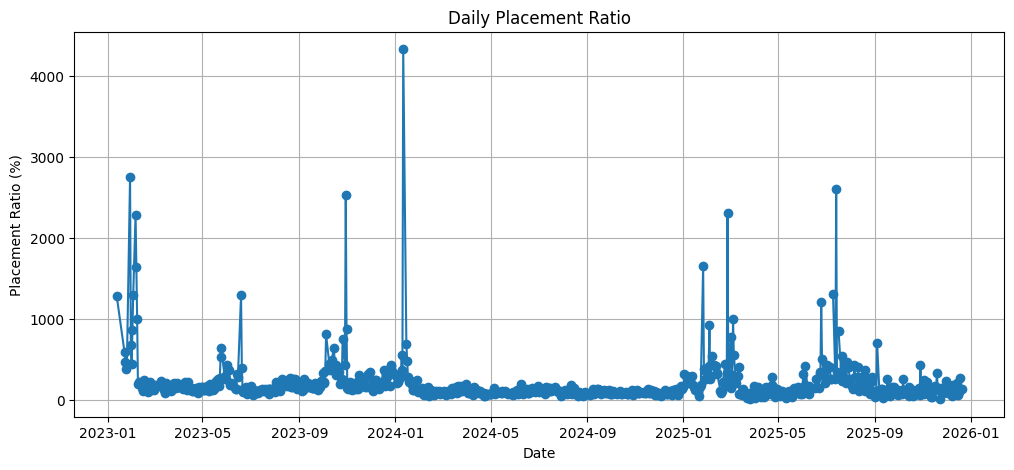

In [36]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Placement_Ratio_%"], marker="o")

plt.title("Daily Placement Ratio")
plt.xlabel("Date")
plt.ylabel("Placement Ratio (%)")
plt.grid(True)

plt.show()

### Rolling Stability

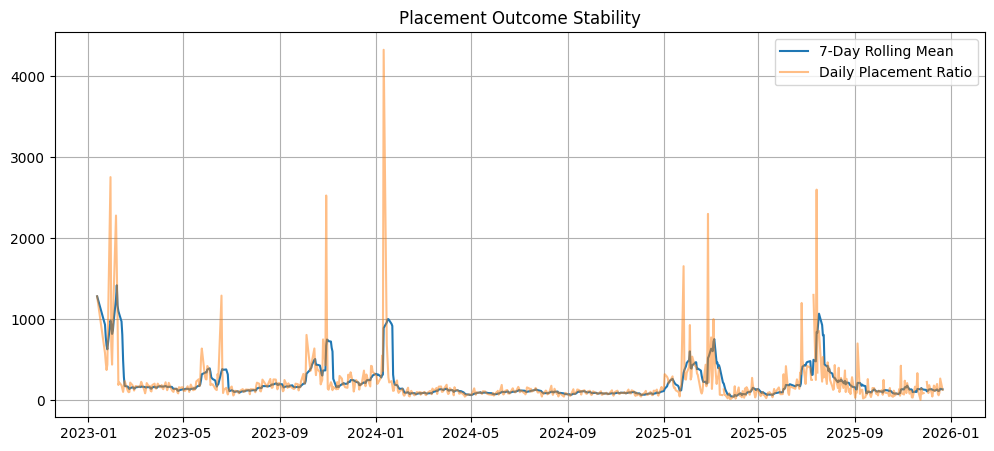

In [37]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Placement_Rolling_Mean"],
    label="7-Day Rolling Mean"
)

plt.plot(
    df["Date"],
    df["Placement_Ratio_%"],
    alpha=0.5,
    label="Daily Placement Ratio"
)

plt.legend()
plt.grid(True)
plt.title("Placement Outcome Stability")

plt.show()

In [38]:
# Saving file


df.to_csv("Analysis.csv", index=False)

print("\nAnalysis completed successfully!")
print("Output saved as 'Analysis.csv'")


Analysis completed successfully!
Output saved as 'Analysis.csv'
